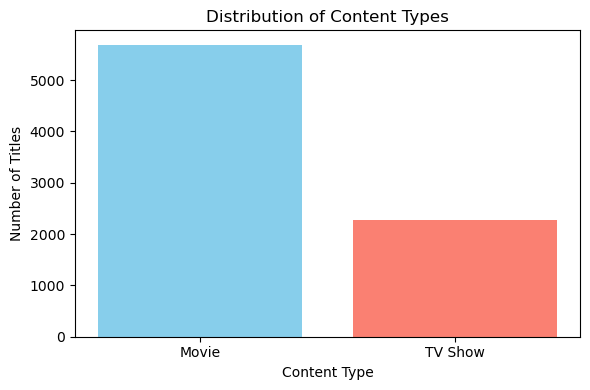

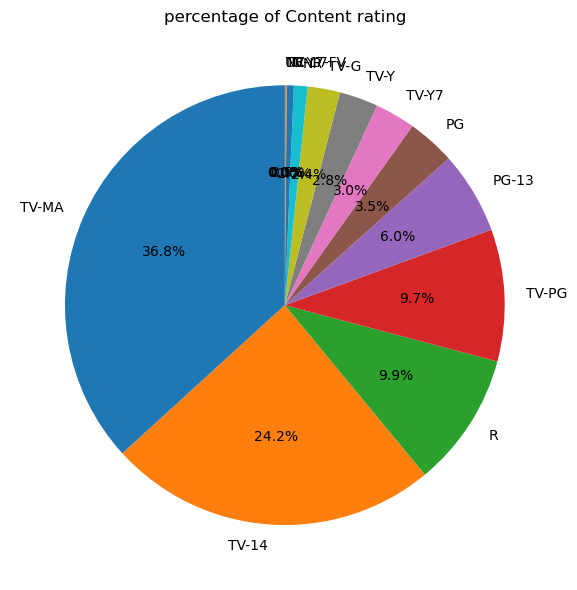

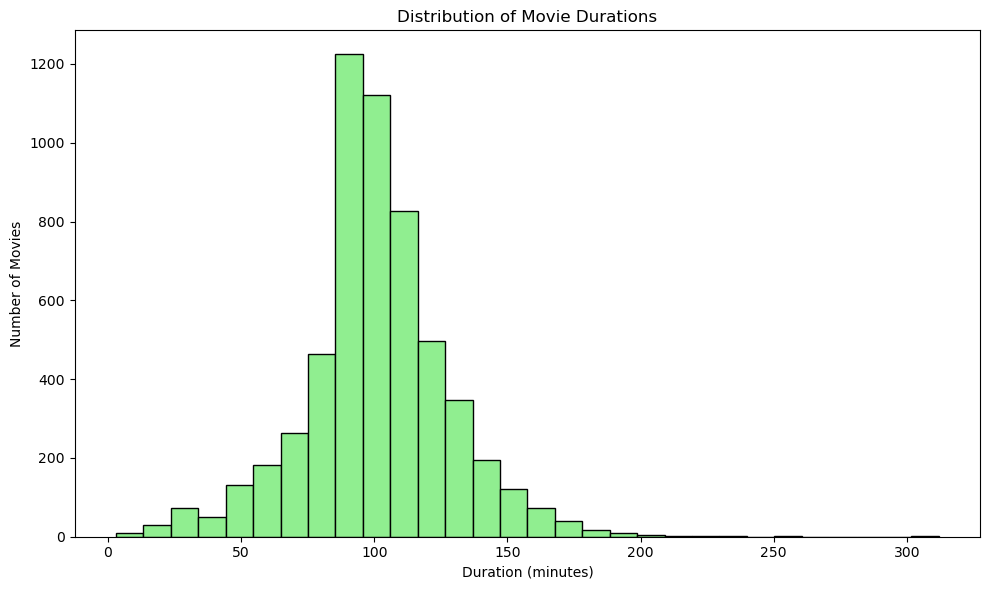

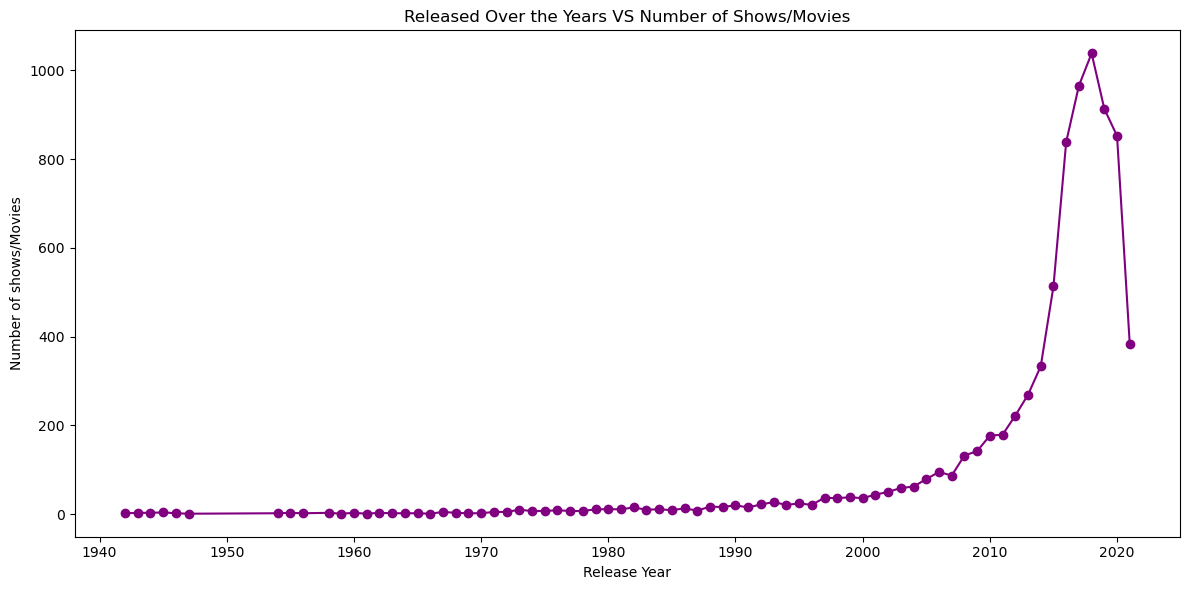

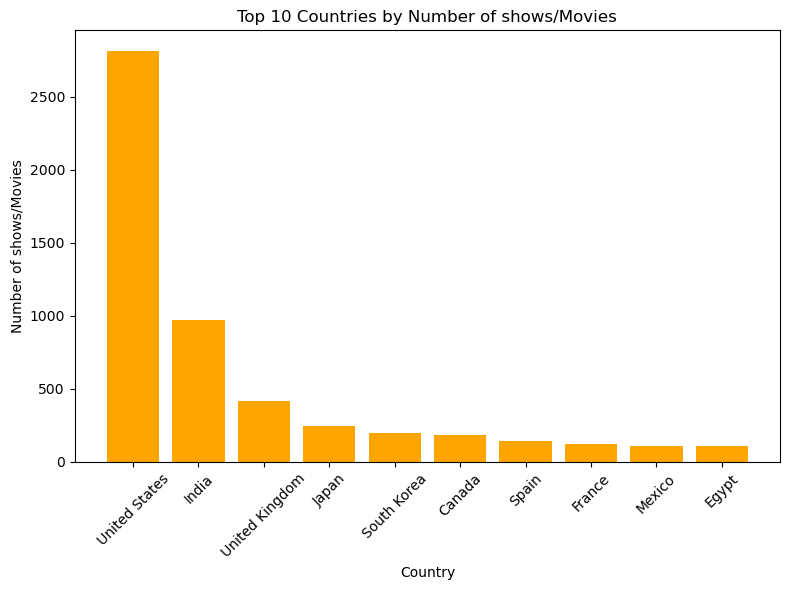

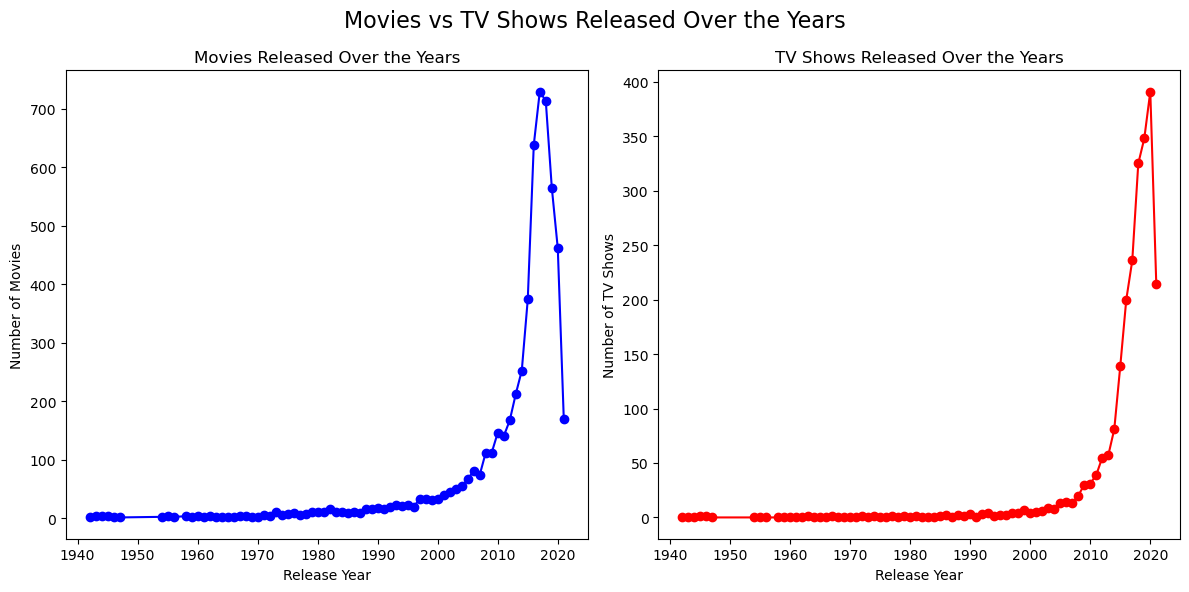

In [10]:
#s-1 import the libraries
import pandas as pd
import matplotlib.pyplot as plt

#load the dataset
data = pd.read_csv('netflix_titles.csv')

#clean data
df = data.dropna(subset=['type', 'release_year', 'rating', 'country', 'duration'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'salmon'])
plt.title('Distribution of Content Types')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('percentage of Content rating')
plt.tight_layout()
plt.savefig('content_ratings_pie.png')
plt.show()


movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(10,6))
plt.hist(movie_df['duration_int'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
#plt.savefig('movie_durations_histogram.png')
plt.show()


release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(release_counts.index, release_counts.values, marker='o', linestyle='-', color='purple')
plt.title('Released Over the Years VS Number of Shows/Movies')
plt.xlabel('Release Year')
plt.ylabel('Number of shows/Movies')
plt.tight_layout()
#plt.savefig('titles_over_years_line.png')
plt.show()


country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.bar(country_counts.index, country_counts.values, color='orange')
plt.title('Top 10 Countries by Number of shows/Movies')
plt.xlabel('Country')
plt.ylabel('Number of shows/Movies')
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig('top_countries_bar.png')
plt.show()  


content_by_year = df.groupby('release_year')['type'].value_counts().unstack().fillna(0)
fig, ax = plt.subplots(1,2, figsize=(12,6))

#first subplot - Movies over the years
ax[0].plot(content_by_year.index, content_by_year['Movie'], marker='o', color='blue')
ax[0].set_title('Movies Released Over the Years')
ax[0].set_xlabel('Release Year')
ax[0].set_ylabel('Number of Movies') 

#second subplot - TV shows over the years
ax[1].plot(content_by_year.index, content_by_year['TV Show'], marker='o', color='red')
ax[1].set_title('TV Shows Released Over the Years')
ax[1].set_xlabel('Release Year')
ax[1].set_ylabel('Number of TV Shows')

fig.suptitle('Movies vs TV Shows Released Over the Years', fontsize=16)

plt.tight_layout()
plt.savefig('movies_vs_tvshows_over_years.png') 
plt.show()